# Simple CNN for Traffic Density Classification

Mục tiêu của notebook là xây dựng một mô hình CNN cơ bản để phân loại ảnh giao thông thành 5 mức mật độ: `Empty`, `Low`, `Medium`, `High` và `Traffic Jam`.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
project_dir = Path.cwd()
if not (project_dir / "src").exists():
    project_dir = project_dir.parent

if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))

from src.data_loader import CLASS_NAMES, create_generators
from src.evaluation import evaluate_model

## 1. Thiết lập thí nghiệm

In [3]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
USE_AUGMENTATION = False

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

`USE_AUGMENTATION=False` được dùng cho mô hình baseline. Có thể đổi thành `True` để chạy lại cùng kiến trúc với augmentation.

## 2. Đọc dữ liệu

In [4]:
train_generator, val_generator, test_generator = create_generators(
    augmentation=USE_AUGMENTATION,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 2707 validated image filenames belonging to 5 classes.
Found 580 validated image filenames belonging to 5 classes.
Found 581 validated image filenames belonging to 5 classes.


In [5]:
print("Class mapping:", train_generator.class_indices)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Class mapping: {'Empty': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Traffic Jam': 4}
Training images: 2707
Validation images: 580
Test images: 581


## 3. Hiển thị một batch ảnh

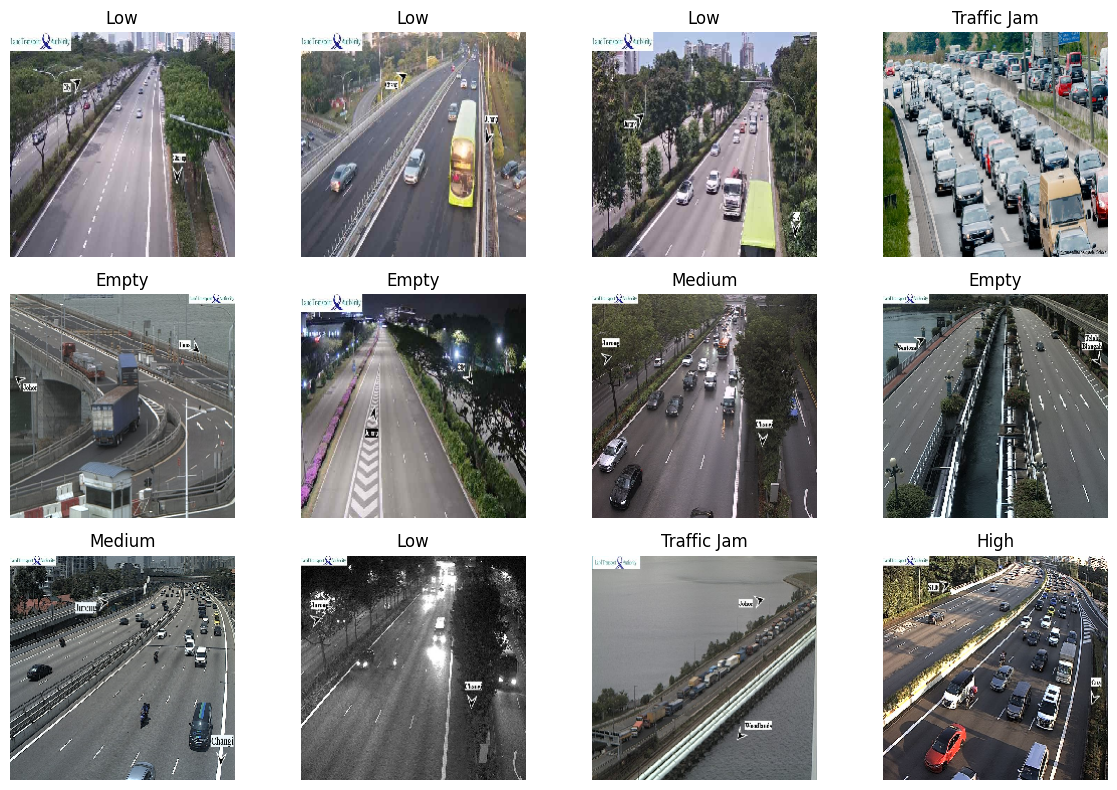

In [6]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for index in range(12):
    plt.subplot(3, 4, index + 1)
    plt.imshow(images[index])
    plt.title(CLASS_NAMES[np.argmax(labels[index])])
    plt.axis("off")

plt.tight_layout()
plt.show()

train_generator.reset()

## 4. Kiến trúc Simple CNN

Mô hình gồm ba tầng convolution để trích xuất đặc trưng, ba tầng max pooling để giảm kích thước đặc trưng và hai tầng fully connected để phân loại.

```text
Input 224×224×3
        ↓
Conv2D: 16 filters, 3×3, ReLU
        ↓
MaxPooling2D: 2×2
        ↓
Conv2D: 32 filters, 3×3, ReLU
        ↓
MaxPooling2D: 2×2
        ↓
Conv2D: 64 filters, 3×3, ReLU
        ↓
MaxPooling2D: 2×2
        ↓
Flatten → Dense 64, ReLU
        ↓
Dense 5, Softmax
```

In [7]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(5, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,792,869 (10.65 MB)

 Trainable params: 2,792,869 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

- `Conv2D` học các đặc trưng như cạnh, hình dạng xe và vùng đường.
- `MaxPooling2D` giảm kích thước feature map và chi phí tính toán.
- `Flatten` chuyển feature map thành một vector.
- `Dense(64)` kết hợp các đặc trưng để phân loại.
- `Dense(5, softmax)` trả về xác suất của 5 lớp.

## 5. Compile model

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

## 6. Huấn luyện model

In [9]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1,
)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 30s 329ms/step - accuracy: 0.5837 - loss: 1.0280 - val_accuracy: 0.6638 - val_loss: 0.7741
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.7104 - loss: 0.7137 - val_accuracy: 0.7586 - val_loss: 0.6342
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step - accuracy: 0.7761 - loss: 0.5768 - val_accuracy: 0.7724 - val_loss: 0.5892
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.8109 - loss: 0.4741 - val_accuracy: 0.7776 - val_loss: 0.5493
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step - accuracy: 0.8570 - loss: 0.3665 - val_accuracy: 0.7655 - val_loss: 0.6126
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step - accuracy: 0.8914 - loss: 0.3025 - val_accuracy: 0.7586 - val_loss: 0.6201
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9165 - loss: 0.2327 - val_accuracy: 0.7879 - val_loss: 0.7767
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - accuracy: 0.9424 - loss: 0.1553 - val_accu

## 7. Training history

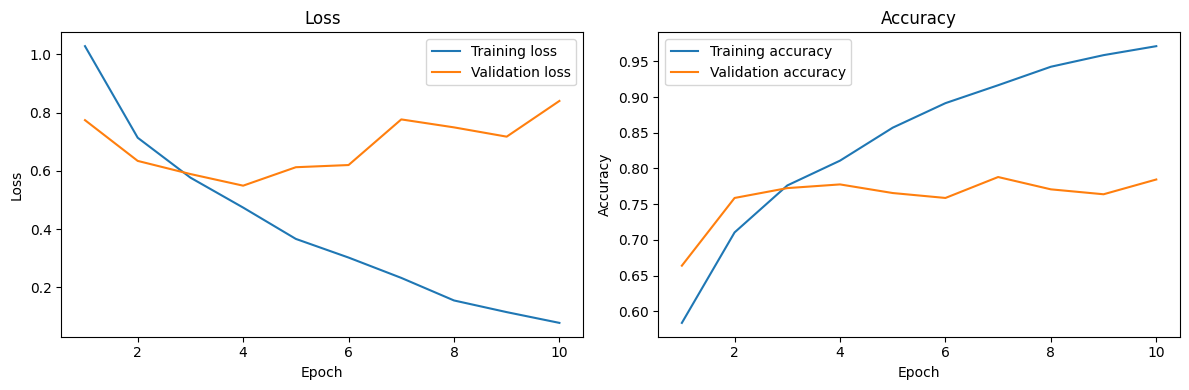

In [10]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["loss"], label="Training loss")
plt.plot(epochs, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history["accuracy"], label="Training accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 8. Đánh giá trên test set

Precision, Recall và F1-score được tính theo macro average để mỗi lớp có mức đóng góp như nhau.

In [11]:
model_name = "Simple CNN + Augmentation" if USE_AUGMENTATION else "Simple CNN"

result = evaluate_model(
    model=model,
    test_generator=test_generator,
    model_name=model_name,
)

result

,Model,Accuracy,Precision,Recall,F1-score
0,Simple CNN,0.7608,0.7459,0.7752,0.7582


## 9. Lưu model

In [12]:
output_dir = project_dir / "outputs"
output_dir.mkdir(exist_ok=True)

model_path = output_dir / "simple_cnn.keras"
model.save(model_path)

print(f"Model saved to: {model_path}")

Model saved to: e:\Documents\DSEB.NEU.7TH\DEEP LEARNING\dl-traffic-density-classi\outputs\simple_cnn.keras
